# Design-Build-Test-Learn, on a loop that can be checked

Most DBTL demonstrations cannot tell you whether they worked. They lay out a
design, produce a response, fit a model, propose a next batch — and stop. The
proposal is never measured, so nothing in the notebook distinguishes a method
that found the optimum from one that wandered.

This notebook uses a library where **every combination has already been
measured**. Urtecho *et al.* (2019) built σ70 promoters as combinations of five
sequence elements and measured RNA expression for 10,898 of them with a
genomically-encoded multiplexed reporter assay. That makes two things possible
that a forward-looking experiment cannot offer:

* the effects estimated from a 64-run design can be compared against the effects
  the full library actually shows, and
* the combinations the optimiser proposes can be **looked up**, so the loop
  closes on real numbers and the notebook can report whether the recommendation
  was right.

**What this is not.** The "experiment" here is a table lookup, not a new
measurement. That is what retrospective validation means, and it is the only way
to test a *method* rather than a *strain*. The measurements are real; the choice
of which ones to reveal is what the design controls.

Findings, up front, because two of them are uncomfortable:

| | |
|---|---|
| 64 runs recover the effects of all 512 combinations | per-level *r* = 0.99 / 0.93 / 0.98 |
| ...and pick the right level of all three factors | ✅ |
| the additive model's recommended combination | ranks **77th of 512** |
| the Gaussian process's predictions of its own proposals | *r* = **−0.19** against measurement |
| ...and yet the batch it proposed | found the **global optimum** |

In [1]:
import pandas as pd

import omicverse as ov
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1 — The part library

`fetch_promoter_library` downloads the measured variant table from GEO
(GSE108535) and caches it. Nothing here is simulated.

In [2]:
library = ov.synbio.fetch_promoter_library()
print(library.shape, '|', library.attrs['source'])
print(library[['minus35', 'minus10', 'expression']].head(3).to_string())

(10898, 8) | GEO GSE108535 (Urtecho et al. 2019, Biochemistry)
         minus35                          minus10  expression
0  35T->A/33G->T                            7T->A    0.142244
1  35T->A/33G->T                     12T->G/7T->C    0.262560
2  34G->T/30A->C  12T->G/11A->T/9A->G/8A->T/7T->A    0.159796


The five elements are the factors, and their levels are part identities — a −35
box, a spacer, a −10 box. **This is what a real design space looks like.** There
is no continuous promoter dial to turn; there is a set of characterised parts and
the question is which one.

In [3]:
for element in ov.synbio.PROMOTER_ELEMENTS:
    print(f'  {element:12s} {library[element].nunique()} levels')
print('full factorial would be', library[list(ov.synbio.PROMOTER_ELEMENTS)].nunique().prod())

  up_element   3 levels
  minus35      8 levels
  spacer       8 levels
  minus10      8 levels
  background   8 levels
full factorial would be 12288


Expression spans two orders of magnitude and its effects are multiplicative, so
everything below works on `log2_expression`. Additive effects on a log response
are fold-changes, which is what a part is usually claimed to have.

In [4]:
print(library['expression'].describe()[['min', '50%', 'max']].round(3).to_string())
print('dynamic range: %.0fx' % (library['expression'].max() / library['expression'].min()))

min     0.057
50%     0.197
max    34.978
dynamic range: 615x


## 2 — Design

Hold the UP element fixed and treat the genomic background as what it is — a
nuisance. That leaves three factors at eight levels each: **512 combinations**.

`combinatorial_design` builds a strength-2 orthogonal array: 64 runs in which
every *pair* of factors sees every level combination equally often, so the
main-effect estimates are mutually uncorrelated. 64 runs instead of 512 is the
entire argument for designing rather than sampling, and it is exact rather than
asymptotic.

In [5]:
one_up = library[library['up_element'] == 'gourse-326fold-up']
elements = {name: sorted(one_up[name].unique()) for name in ('minus35', 'spacer', 'minus10')}
design = ov.synbio.combinatorial_design(elements, design='orthogonal_array', seed=0)
print(design)

PartDesign(orthogonal_array, 64 runs, 3 factors, full would be 512)


In [6]:
print(design.balance().to_string())
for note in design.notes:
    print(' -', note)

         levels  min_count  max_count  balanced
factor                                         
minus35       8          8          8      True
spacer        8          8          8      True
minus10       8          8          8      True
 - 强度 2 正交表:64 次实验覆盖 3 个 8 水平因子(全组合要 512 次)。任意两因子的每个水平组合恰好出现一次,主效应估计互不相关。
 - 三因子及更高阶交互与主效应混淆 —— 与 resolution IV 部分因子同理。


Balance is not a formality — it is the whole claim. If a level of one factor
turns up more often alongside a particular level of another, their effects are
partly confounded and the ranking that comes out is not interpretable. The right
panel is the check: every cell of the pairwise crosstab holds the same count.

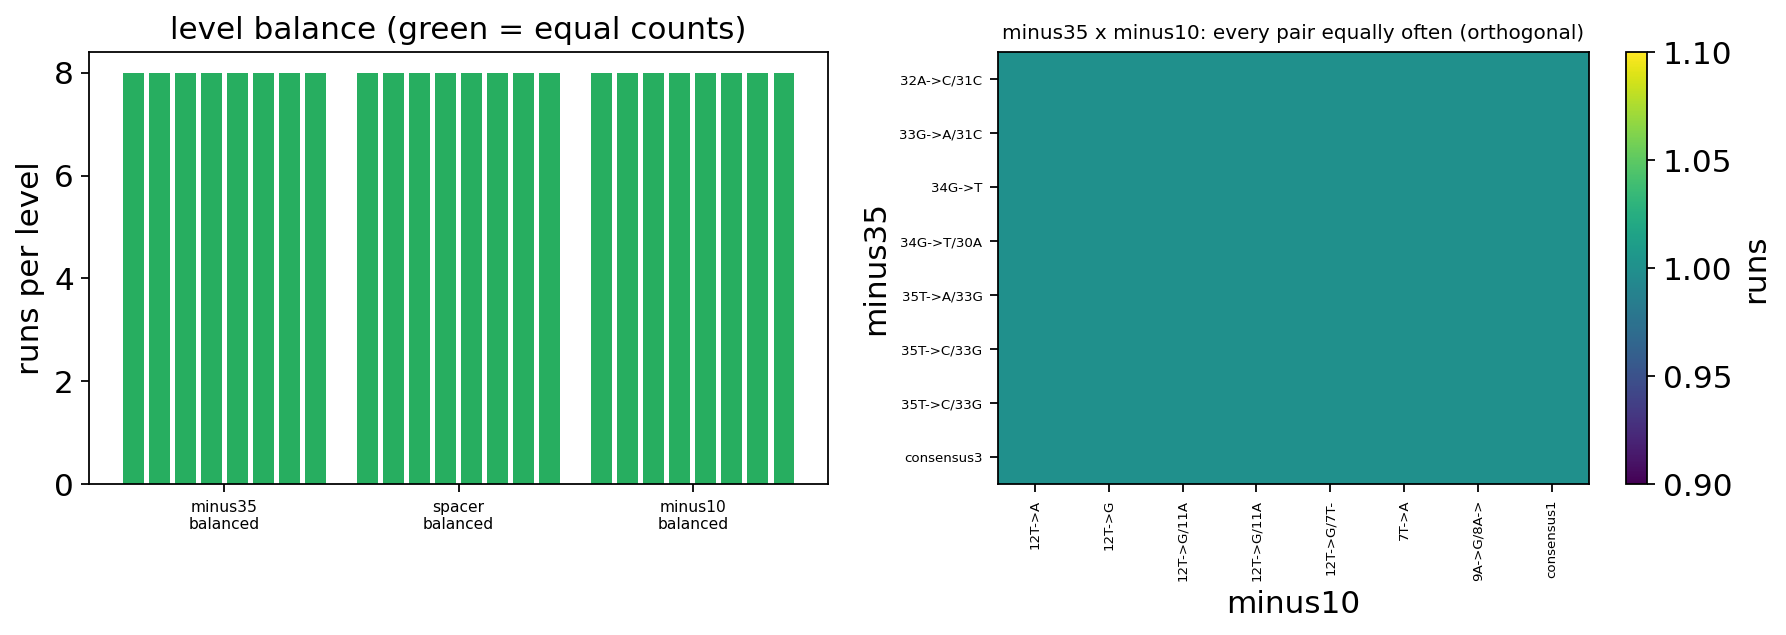

In [7]:
ov.synbio.plot_design_balance(design, pair=('minus35', 'minus10'))
None

## 3 — Build and Test, retrospectively

In a forward experiment this is where the constructs get assembled and measured.
Here the measurement already exists, so "running the experiment" is a join.

One real decision first: the genomic background is a **block**, not a factor. You
choose the promoter elements; you do not choose where the reporter lands. Its
effect is averaged over rather than optimised, which also cuts the measurement
noise by √8.

In [8]:
per_combination = one_up.groupby(list(elements))['log2_expression'].agg(['mean', 'std', 'size'])
per_combination = per_combination.rename(columns={'mean': 'log2_expression'}).reset_index()
print(f'{len(per_combination)} element combinations, median {int(per_combination["size"].median())} backgrounds each')
print('between-combination SD %.2f vs within %.2f -> signal/noise %.1f' % (
    per_combination['log2_expression'].std(), per_combination['std'].median(),
    per_combination['log2_expression'].std() / per_combination['std'].median()))

512 element combinations, median 7 backgrounds each
between-combination SD 2.05 vs within 0.45 -> signal/noise 4.5


In [9]:
round1 = design.to_frame().merge(per_combination, on=list(elements), how='left')
measured1 = round1.dropna(subset=['log2_expression'])
print(f'{len(measured1)}/{design.n_runs} designed combinations were built and measured')
print('best in round 1: %.3f log2' % measured1['log2_expression'].max())

64/64 designed combinations were built and measured
best in round 1: 3.617 log2


All 64 exist here. They will not always: a design asks for combinations that a
library may never have contained, and clones fail. `analyse_parts` takes what
came back rather than requiring a complete design.

## 4 — Learn

Per-level effects, effects-coded so each one reads as "this level against the
average level". A blocked orthogonal array has residual degrees of freedom, so
this gets a real F-test rather than Lenth's approximation for unreplicated
screens.

In [10]:
effects = ov.synbio.analyse_parts(measured1[list(elements)], measured1['log2_expression'],
                                  response_name='log2 expression')
print(effects)
print(effects.factor_frame().round(4).to_string())

PartEffects(64 runs, R²=0.715, df_resid=42, top: ['minus35=0.358', 'minus10=0.287', 'spacer=0.070'])
         n_levels  variance_explained  effect_spread    best_level  p_value
factor                                                                     
minus35         8              0.3579         3.6298   consensus35   0.0000
minus10         8              0.2873         3.0664   consensus10   0.0001
spacer          8              0.0696         1.5024  ECK125137726   0.2067


−35 and −10 dominate; the spacer is a minor term. That is the paper's central
finding, recovered from an eighth of the library.

The right-hand panel is the actionable output: the effect of every −35 box, so
you can read off which part to use.

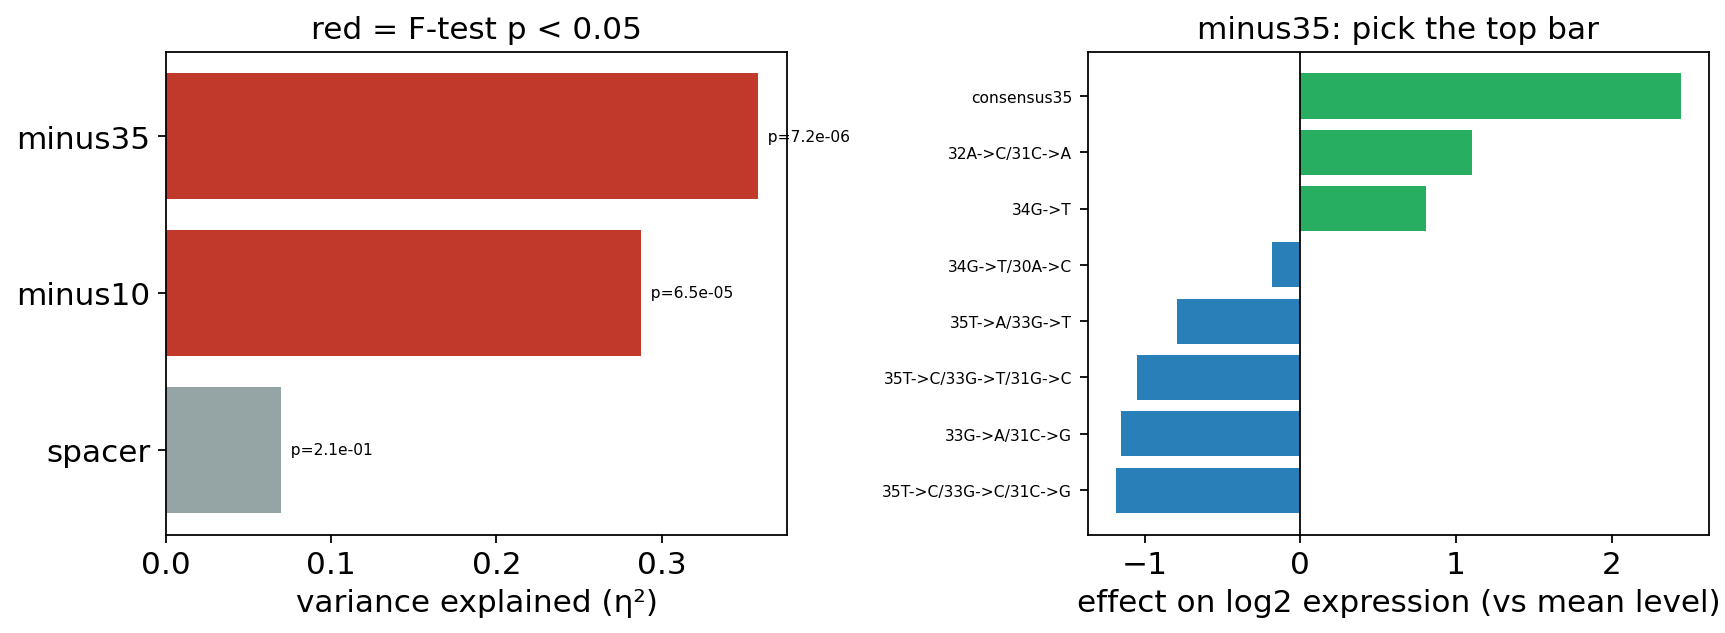

In [11]:
ov.synbio.plot_part_effects(effects, factor='minus35')
None

### 4.1 Did the design actually work?

This is the question a normal DBTL notebook cannot ask. Compute the same effects
from **all 512 measured combinations** and compare.

In [12]:
truth = ov.synbio.analyse_parts(per_combination[list(elements)],
                                per_combination['log2_expression'])
comparison = ov.synbio.compare_part_effects(effects, truth)
print(comparison.round(4).to_string(index=False))

 factor  n_levels_compared  effect_r  eta2_estimate  eta2_reference best_level_estimate best_level_reference  best_level_agrees
minus35                  8    0.9941         0.3579          0.3422         consensus35          consensus35               True
minus10                  8    0.9822         0.2873          0.2975         consensus10          consensus10               True
 spacer                  8    0.9307         0.0696          0.0637        ECK125137726         ECK125137726               True


Per-level effects correlate at *r* = 0.99, 0.93 and 0.98 with the full-library
truth, and all three best levels are identified correctly. **64 runs bought the
answer that 512 would have given.**

### 4.2 Where the additive model is wrong

Now the uncomfortable part. The additive model has a recommended combination —
the best level of each factor. Look it up.

In [13]:
recommended = truth.best_levels()
lookup = ov.synbio.lookup_combination(per_combination, recommended)
best_anywhere = per_combination['log2_expression'].max()
print('additive recommendation:', recommended)
print('measured %.3f vs the library best %.3f' % (lookup['log2_expression'].iloc[0], best_anywhere))

additive recommendation: {'minus35': 'consensus35', 'spacer': 'ECK125137726', 'minus10': 'consensus10'}
measured 1.948 vs the library best 4.192


In [14]:
rank = int((per_combination['log2_expression'] > lookup['log2_expression'].iloc[0]).sum()) + 1
print(f'that combination ranks {rank}/{len(per_combination)}')
print('it reaches %.0f%% of the best expression in the library' % (
    100 * 2 ** (lookup['log2_expression'].iloc[0] - best_anywhere)))
print('additive model R² over all %d combinations: %.3f' % (len(per_combination), truth.r_squared))

that combination ranks 77/512
it reaches 21% of the best expression in the library
additive model R² over all 512 combinations: 0.703


**The additive optimum ranks 77th of 512 and reaches 21% of the best.**

The model is not broken — it explains 70% of the variance and it got the factor
ranking right. But 30% is interaction, and "best level of each factor
independently" is not the best combination when elements interact. A screening
design tells you *which knobs matter*. It does not tell you where to set them
jointly.

That is the argument for a second round, and it is an argument the additive
analysis cannot make about itself.

## 5 — Round 2: back to Design

`propose_combinations` runs Bayesian optimisation restricted to a **catalogue of
combinations that can actually be built**. The continuous optimiser will happily
return `promoter = 0.672`, and there is no such promoter.

In [15]:
proposal = ov.synbio.propose_combinations(measured1[list(elements)],
                                          measured1['log2_expression'],
                                          per_combination[list(elements)],
                                          batch=8, acquisition='ei', seed=0)
print(proposal)
for note in proposal.notes:
    print(' -', note)

CombinationProposal(8 from 448 candidates, ei, best so far 3.617)
 - 目录里有 64 个组合已经测过,已排除。


In [16]:
round2 = proposal.to_frame()
round2 = round2.merge(per_combination[list(elements) + ['log2_expression']],
                      on=list(elements), how='left').rename(columns={'log2_expression': 'measured'})
print(round2[['minus35', 'spacer', 'minus10', 'predicted', 'uncertainty', 'measured']].round(3).to_string())

         minus35        spacer      minus10  predicted  uncertainty  measured
0    consensus35     P1-6-17bp  consensus10      3.783        1.337     1.830
1    consensus35     P1-6-17bp       12T->G      3.543        1.272     3.856
2    consensus35  ECK125137104  consensus10      3.411        1.252     2.111
3    consensus35     P1-6-17bp       12T->A      3.179        1.197     4.192
4    consensus35  ECK125137108  consensus10      2.889        1.190     1.345
5  32A->C/31C->A  ECK125137726  consensus10      2.665        1.240     2.969
6  32A->C/31C->A  ECK125137726       12T->A      2.526        1.184     3.030
7    consensus35  ECK125137108       12T->G      2.590        1.115     3.715


### 5.1 The proposals were good. The predictions were not.

Read the last two columns against each other before reading anything else.

In [17]:
print('predicted vs measured over the 8 proposals: r = %.3f' % (
    round2['predicted'].corr(round2['measured'])))
print('round 2 best %.3f | round 1 best %.3f | library best %.3f' % (
    round2['measured'].max(), measured1['log2_expression'].max(), best_anywhere))

predicted vs measured over the 8 proposals: r = -0.188
round 2 best 4.192 | round 1 best 3.617 | library best 4.192


**The Gaussian process's point predictions are anti-correlated with the
measurements (*r* = −0.19), and the batch it chose still found the global
optimum.**

These are not in tension. Expected improvement does not reward accurate
prediction; it rewards sampling where the posterior is uncertain *and* plausibly
high. With 64 observations one-hot-encoded over a 512-point space the surrogate
is close to a lookup table — it interpolates its training points and reverts to
the prior elsewhere, which is exactly why its `uncertainty` column is large and
its `predicted` column is nearly flat.

The practical rule: **do not report a GP's predicted values as expectations for
the next round.** Report them as a search direction. The `uncertainty` column is
doing the work.

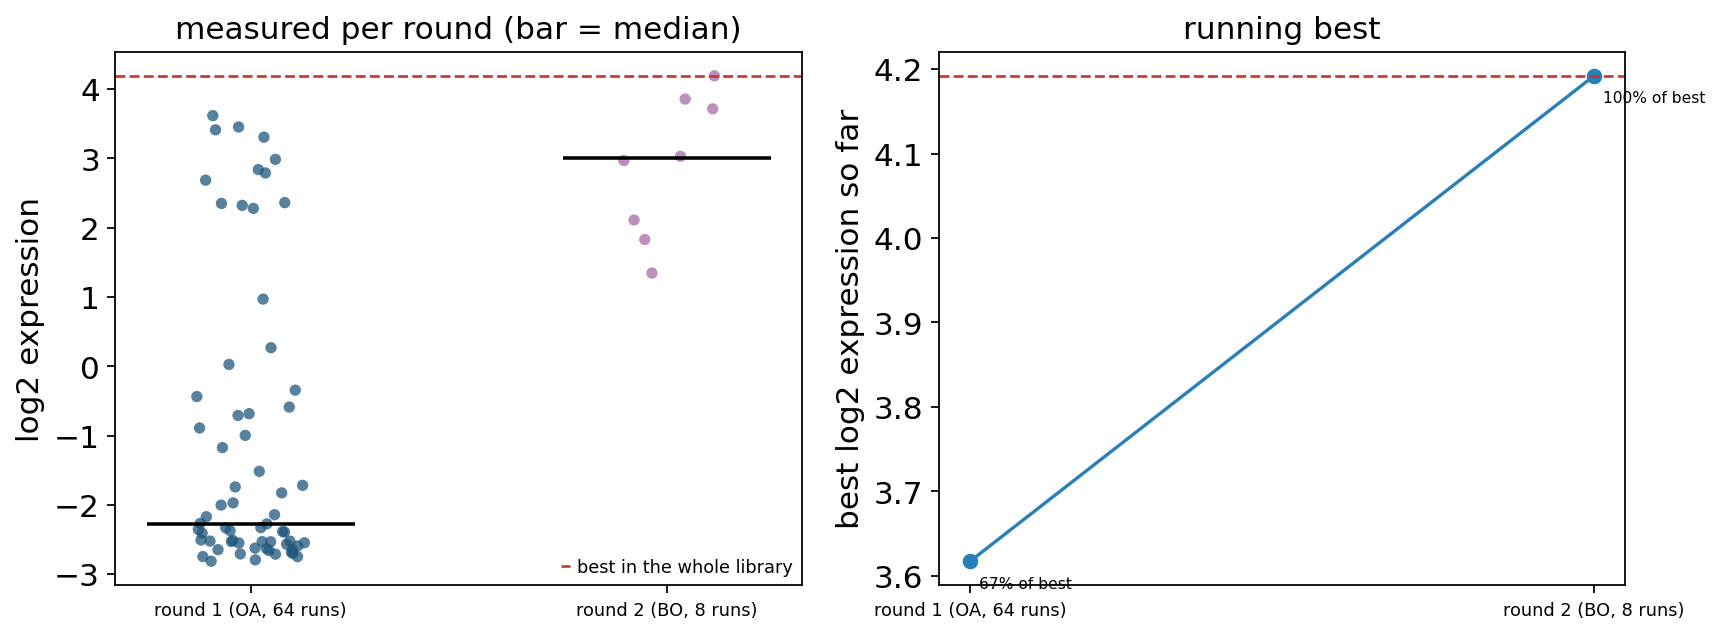

In [18]:
ov.synbio.plot_round_progress({'round 1 (OA, 64 runs)': measured1['log2_expression'],
                               'round 2 (BO, 8 runs)': round2['measured']},
                              best_possible=best_anywhere,
                              response_name='log2 expression')
None

72 measurements out of 512 — 14% of the library — reached the best promoter in
it. Round 1 alone was at 67%.

## 6 — What makes it a cycle

Round 3 is the same call with both rounds' observations concatenated. Two things
have to happen: the already-measured combinations are excluded, and — since round
2 already reached the library optimum — nothing further should be found. An
optimiser that keeps reporting improvement on an exhausted space is broken, so
this is a check, not a victory lap.

In [19]:
already = pd.concat([measured1[list(elements) + ['log2_expression']],
                     round2[list(elements) + ['measured']].rename(
                         columns={'measured': 'log2_expression'})], ignore_index=True)
print(f'{len(already)} combinations measured, best {already["log2_expression"].max():.3f}')

72 combinations measured, best 4.192


In [20]:
round3 = ov.synbio.propose_combinations(already[list(elements)], already['log2_expression'],
                                        per_combination[list(elements)], batch=8, seed=0)
print(round3)
for note in round3.notes:
    print(' -', note)

CombinationProposal(8 from 440 candidates, ei, best so far 4.192)
 - 目录里有 72 个组合已经测过,已排除。


In [21]:
looked_up = [ov.synbio.lookup_combination(per_combination, combo)['log2_expression'].iloc[0]
             for combo in round3.combinations]
print('round 3 best %.3f | best so far %.3f | library best %.3f' % (
    max(looked_up), already['log2_expression'].max(), best_anywhere))
print('improvement: %+.3f log2' % (max(looked_up) - already['log2_expression'].max()))

round 3 best 3.948 | best so far 4.192 | library best 4.192
improvement: -0.244 log2


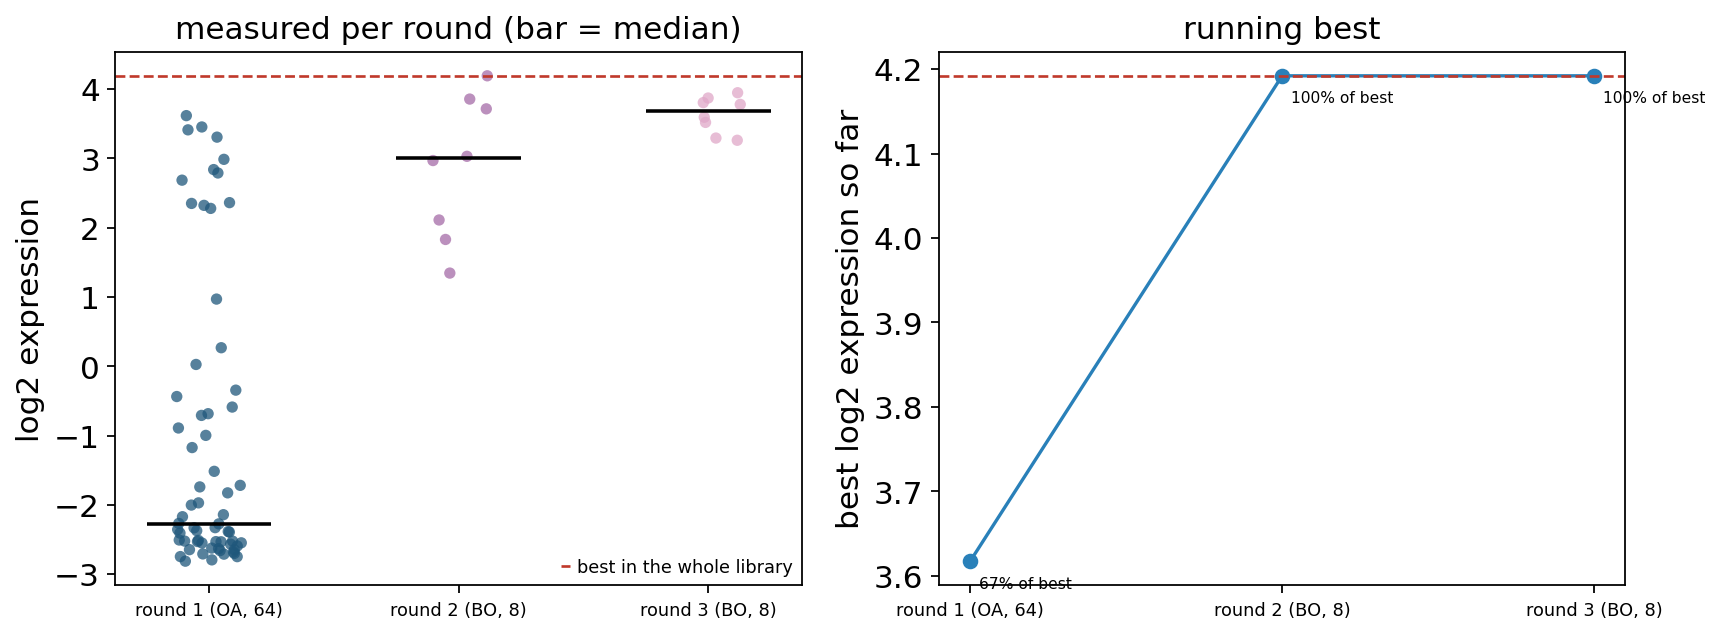

In [22]:
ov.synbio.plot_round_progress({'round 1 (OA, 64)': measured1['log2_expression'],
                               'round 2 (BO, 8)': round2['measured'],
                               'round 3 (BO, 8)': looked_up},
                              best_possible=best_anywhere,
                              response_name='log2 expression')
None

## What to carry away

**Two tools, two jobs.** The screening design ranked the factors correctly from
64 runs — that is what it is for. It also produced a recommended combination that
ranks 77th of 512, because 30% of the variance is interaction. The optimiser
found the best combination in the library from 8 further experiments — and its
predicted values were anti-correlated with what those experiments measured.

Using either alone gets you a wrong answer with a plausible number attached. The
screen tells you what to vary; the optimiser tells you what to try next; neither
tells you what you will measure.

**Two honest limits of this notebook.**

1. The experiment is a lookup. That tests the method, not a strain, and it is the
   only way to know whether the method works at all — but a real round has
   assembly failures, plate effects and drift that a join does not.
2. Ten of the 64 designed combinations would have been missing had a different
   UP element been chosen, and `analyse_parts` would have proceeded on 54. Design
   completeness is not guaranteed by design *balance*.

**Where the numbers came from.** Urtecho G, Tripp AD, Insigne KD, Kim H,
Kosuri S. *Biochemistry* 58, 1539–1551 (2019); GEO GSE108535.